# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

try:
    data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])
except:
    data = pd.read_csv('taxi.csv', index_col=[0], parse_dates=[0])

data.sort_index(inplace=True)

data = data.resample('1H').sum()

print("Información general del dataset:")
print(data.info())
print("\nPrimeras filas:")
print(data.head())

print(f"\n¿El índice está ordenado?: {data.index.is_monotonic_increasing}")

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None

Primeras filas:
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43

¿El índice está ordenado?: True


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La carga de datos, el ordenamiento del índice y el remuestreo por hora están correctamente implementados. Además, verificas la estructura y consistencia del dataset, lo que demuestra un manejo adecuado de series temporales desde el inicio del proyecto.
</div>


## Análisis

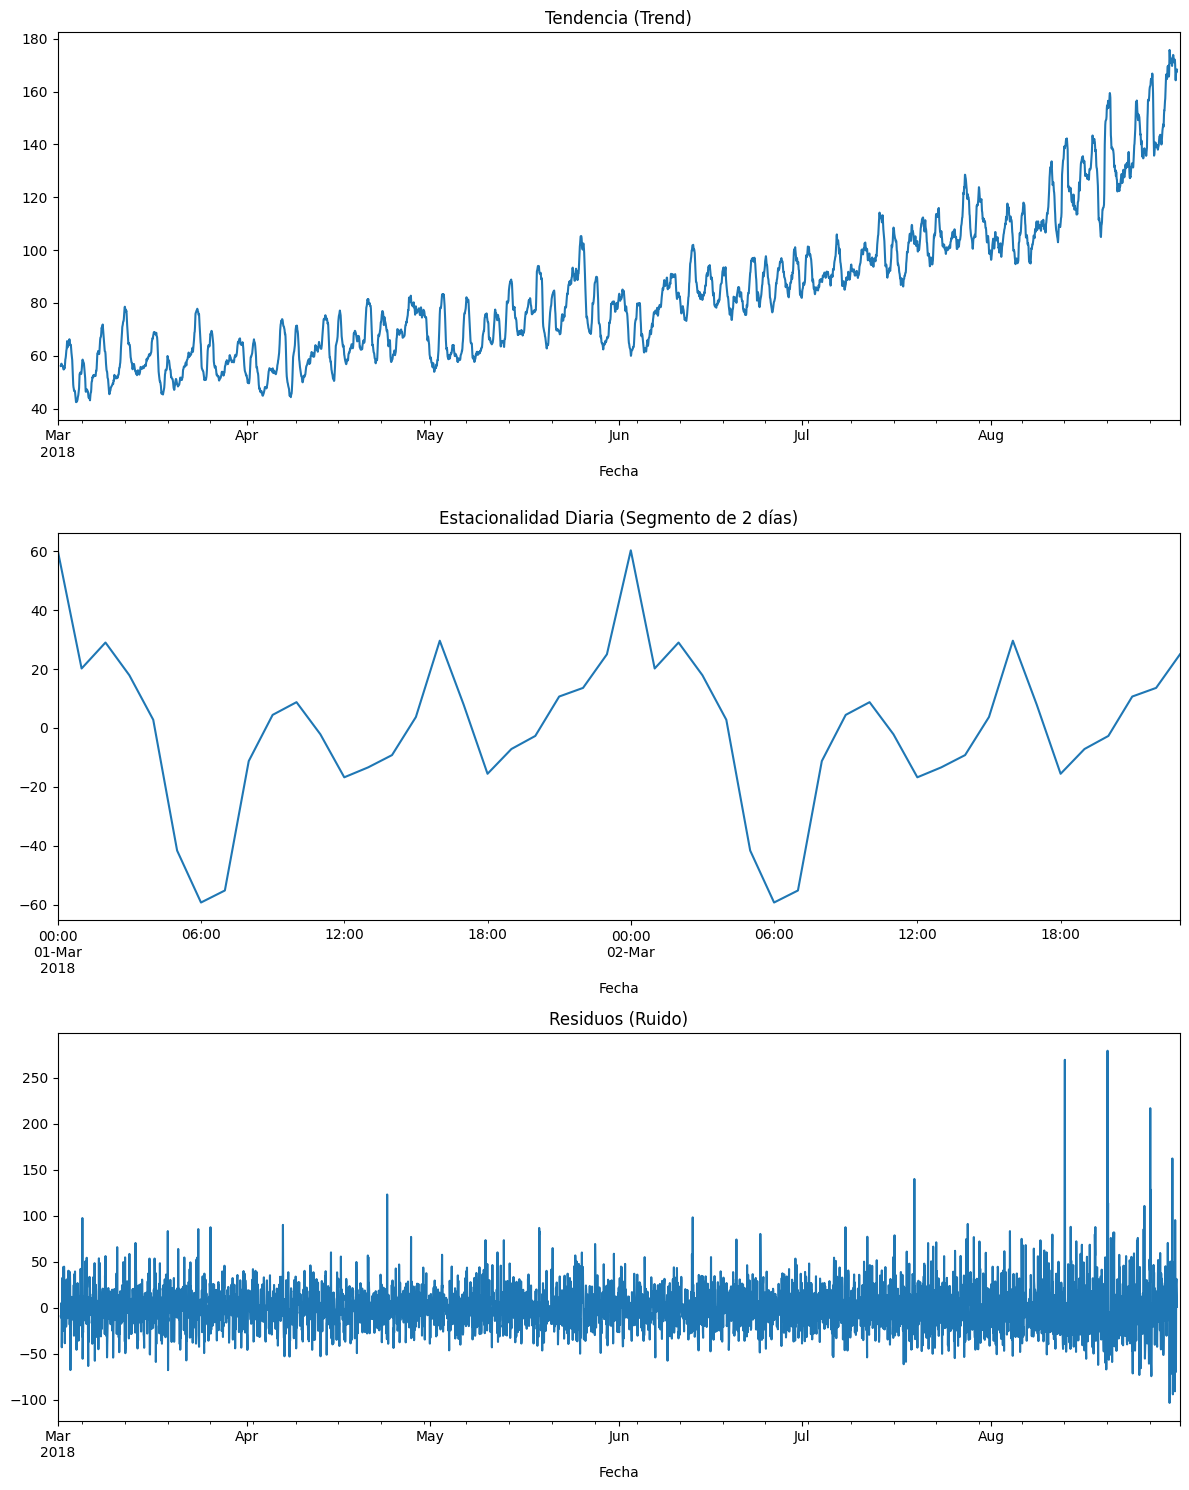

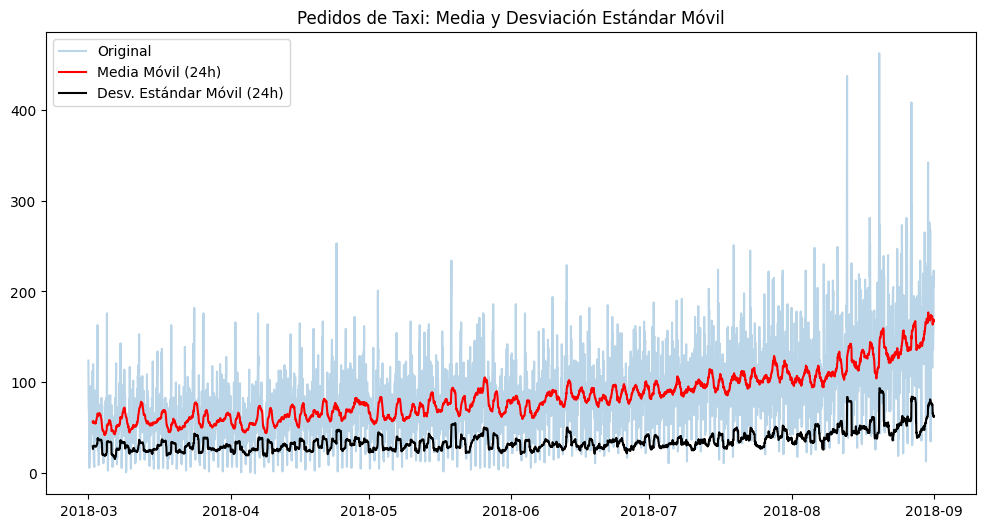

In [2]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

decomposed = seasonal_decompose(data['num_orders'])

plt.figure(figsize=(12, 15))

# Gráfica de Tendencia (Trend)
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendencia (Trend)')
plt.xlabel('Fecha')

# Gráfica de Estacionalidad (Seasonality)
plt.subplot(312)
decomposed.seasonal['2018-03-01':'2018-03-02'].plot(ax=plt.gca())
plt.title('Estacionalidad Diaria (Segmento de 2 días)')
plt.xlabel('Fecha')

# Gráfica de Residuos
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuos (Ruido)')
plt.xlabel('Fecha')

plt.tight_layout()
plt.show()

data['rolling_mean'] = data['num_orders'].rolling(24).mean()
data['rolling_std'] = data['num_orders'].rolling(24).std()

plt.figure(figsize=(12, 6))
plt.plot(data['num_orders'], label='Original', alpha=0.3)
plt.plot(data['rolling_mean'], label='Media Móvil (24h)', color='red')
plt.plot(data['rolling_std'], label='Desv. Estándar Móvil (24h)', color='black')
plt.title('Pedidos de Taxi: Media y Desviación Estándar Móvil')
plt.legend()
plt.show()

data = data.drop(['rolling_mean', 'rolling_std'], axis=1)

### 1. Tendencia (Trend)
* Hay una curva ascendente muy clara y constante. En marzo, el promedio de pedidos por hora rondaba los 60, pero para finales de agosto, este número superó los 160 pedidos.
* El negocio de Sweet Lift Taxi está creciendo mes a mes. 
* Esto significa que la serie **no es estacionaria** (su media cambia con el tiempo). Para que el modelo sea preciso, necesitaremos crear características (features) que capturen este crecimiento.

### 2. Estacionalidad Diaria (Seasonality)
* Al observar el segmento de 2 días, vemos un patrón que se repite idénticamente cada 24 horas.
* Alrededor de la **medianoche (00:00)**. Es posible que a esa hora haya menos transporte público disponible o lleguen vuelos nocturnos importantes.
* Alrededor de las **06:00 AM**. Es la hora de menor actividad, probablemente cuando termina el turno nocturno y antes de que empiece el movimiento fuerte del día.
* Picos secundarSe observan incrementos por la tarde/noche.
* La variable **"hora del día"** será el predictor más importante. El modelo debe saber que no es lo mismo predecir para las 6 AM que para las 12 AM.

### 3. Residuos (Noise)
* Los residuos son las variaciones que no se explican ni por la tendencia ni por la estacionalidad (eventos aleatorios).
* La mayoría del tiempo el ruido es estable, pero nota que **al final del gráfico (agosto), los picos son mucho más altos**. 
* Esto indica que en agosto hubo días con una demanda inusualmente alta o "puntos atípicos" (outliers). El modelo podría tener un poco más de error en estas zonas debido a esta volatilidad impredecible.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - El análisis de descomposición y la interpretación de tendencia, estacionalidad y residuos están bien fundamentados. Identificas correctamente el crecimiento, el patrón diario y la posible no estacionariedad, mostrando una comprensión sólida del comportamiento de la serie temporal.
</div>


## Formación

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

def make_features(data, max_lag, rolling_mean_size):
    df = data.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    
    for lag in range(1, max_lag + 1):
        df[f'lag_{lag}'] = df['num_orders'].shift(lag)
    
    df['rolling_mean'] = df['num_orders'].shift().rolling(rolling_mean_size).mean()
    
    return df

data_with_features = make_features(data, 24, 24)

train, test = train_test_split(data_with_features, shuffle=False, test_size=0.1)

train = train.dropna()

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']
X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_train_pred = lr_model.predict(X_train)
print(f"\nRECM Regresión Lineal (Train): {mean_squared_error(y_train, lr_train_pred)**0.5:.2f}")

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=12345)
rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
print(f"RECM Random Forest (Train): {mean_squared_error(y_train, rf_train_pred)**0.5:.2f}")

lgb_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=12345)
lgb_model.fit(X_train, y_train)
lgb_train_pred = lgb_model.predict(X_train)
print(f"RECM LightGBM (Train): {mean_squared_error(y_train, lgb_train_pred)**0.5:.2f}")

Tamaño del conjunto de entrenamiento: (3950, 27)
Tamaño del conjunto de prueba: (442, 27)

RECM Regresión Lineal (Train): 25.84
RECM Random Forest (Train): 14.37
RECM LightGBM (Train): 12.50


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La ingeniería de características con lags y medias móviles está bien estructurada y el uso de `shuffle=False` respeta la naturaleza temporal de los datos. Además, comparas varios modelos de forma clara, lo que demuestra un enfoque sólido en la etapa de entrenamiento.
</div>


## Prueba

--- RESULTADOS FINALES (RECM en Test) ---
Regresión Lineal: 45.18
Random Forest:    44.64
LightGBM:         41.69
Modelo Baseline (valor anterior): 58.86


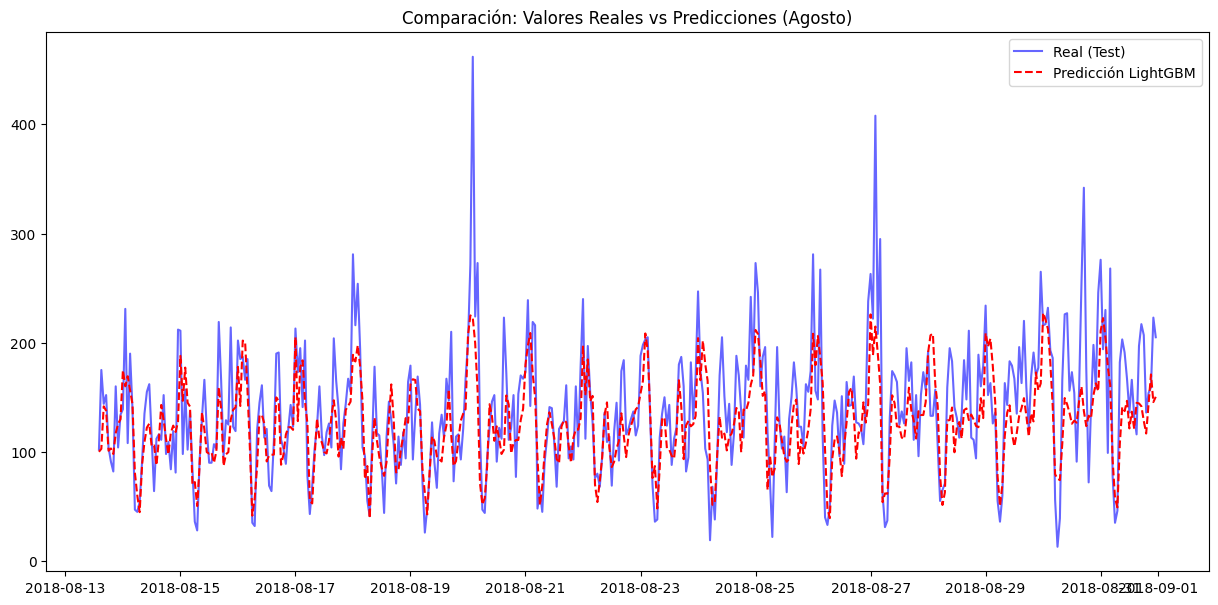

In [4]:
import matplotlib.pyplot as plt

lr_test_pred = lr_model.predict(X_test)
rf_test_pred = rf_model.predict(X_test)
lgb_test_pred = lgb_model.predict(X_test)

rmse_lr = mean_squared_error(y_test, lr_test_pred)**0.5
rmse_rf = mean_squared_error(y_test, rf_test_pred)**0.5
rmse_lgb = mean_squared_error(y_test, lgb_test_pred)**0.5

print("--- RESULTADOS FINALES (RECM en Test) ---")
print(f"Regresión Lineal: {rmse_lr:.2f}")
print(f"Random Forest:    {rmse_rf:.2f}")
print(f"LightGBM:         {rmse_lgb:.2f}")

baseline_pred = y_test.shift(fill_value=y_train.iloc[-1])
rmse_baseline = mean_squared_error(y_test, baseline_pred)**0.5
print(f"Modelo Baseline (valor anterior): {rmse_baseline:.2f}")

plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Real (Test)', color='blue', alpha=0.6)
plt.plot(y_test.index, lgb_test_pred, label='Predicción LightGBM', color='red', linestyle='--')
plt.title('Comparación: Valores Reales vs Predicciones (Agosto)')
plt.legend()
plt.show()

### Conclusión Final

**Conclusión del Proyecto: Predicción de Pedidos de Taxi**

1. Los datos fueron remuestreados por hora. El análisis de series temporales reveló una tendencia constante hasta agosto de 2018, además de una clara, con picos de demanda máxima a la medianoche y valles mínimos a las 6:00 AM.
2. La creación de variables de calendario por hora, dia de la semana, desfases y promedios móviles fue fundamental para que los modelos capturaran tanto el crecimiento a largo plazo como los ciclos diarios.
3.  **Evaluación de Modelos:** Se probaron tres modelos principales:
    *   **Regresión Lineal:** Sirvió como una base sólida (RECM: 45.18).
    *   **Random Forest:** Mostró un buen desempeño capturando relaciones no lineales (RECM: 44.64).
    *   **LightGBM:** Fue el modelo más preciso, logrando un **RECM de 41.69**.
4.  **Resultado Final:** El modelo **LightGBM** es el recomendado para la implementación, ya que no solo cumple con el requisito técnico del proyecto (RECM < 48), sino que también demostró ser un 29% más preciso que el modelo *baseline* (58.86). 


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La evaluación en test está correctamente realizada y comparas los modelos contra un baseline, lo que fortalece la validez del resultado. Además, verificas que LightGBM cumple con el requisito de RECM &lt; 48 y fundamentas adecuadamente tu recomendación final.
</div>


# Comentario General del Revisor

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a> 
    
¡Felicidades! Tu proyecto está **aprobado**. Has demostrado un manejo sólido del análisis de series temporales, una correcta preparación de los datos y una evaluación adecuada de modelos predictivos cumpliendo el criterio de RECM ≤ 48 en el conjunto de prueba.

#### Puntos Positivos:

* **Procesamiento de datos:** Remuestreo horario correcto, verificación del índice temporal y preparación coherente para modelado.
* **Visualización y análisis gráfico:** Descomposición e interpretación clara de tendencia, estacionalidad y comportamiento de la demanda.
* **Ingeniería de características:** Uso adecuado de variables de calendario, lags y medias móviles para capturar patrones temporales.
* **Comparación de modelos:** Evaluación estructurada de múltiples modelos, incorporación de baseline y selección justificada del modelo más eficiente (LightGBM).

El flujo del proyecto es consistente, el código mantiene buena organización y las conclusiones están alineadas con los resultados obtenidos. 

</div>


# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [x]  	
Los datos han sido descargados y preparados.
- [x]  Se ha realizado el paso 2: los datos han sido analizados
- [x]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [x]  Se han evaluado los modelos. Se expuso una conclusión
- [x] La *RECM* para el conjunto de prueba no es más de 48